
## Introduction

This notebook performs an Exploratory Data Analysis (EDA) on a dataset containing Amazon product sales information. The goal of this analysis is to understand the characteristics of the data, identify patterns, relationships between variables, and uncover insights that could be valuable for business decisions, such as optimizing pricing strategies, marketing efforts, or product development.

The dataset includes details such as product ratings, reviews, purchase frequency, pricing, discount information, and product categories.

## Libraries Used

This notebook utilizes the following Python libraries for data analysis and visualization:

pandas (pd): A powerful library for data manipulation and analysis. It's used for reading data, handling DataFrames, cleaning data, and performing various data transformations.

numpy (np): The fundamental package for numerical computing in Python. It's often used in conjunction with pandas for array operations.

matplotlib.pyplot (plt): A comprehensive library for creating static, animated, and interactive visualizations in Python. It's used for plotting charts and customizing their appearance.

seaborn (sns): A data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics, making it easier to create complex plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Initial Inspection

First, we load the `amazon_products_sales_data_cleaned.csv` file into a pandas DataFrame and perform an initial inspection to understand its structure, data types, and identify any immediate issues like missing values or duplicates.

In [ ]:
df=pd.read_csv('/content/amazon_products_sales_data_cleaned.csv')
df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [ ]:
#Data Types and Non-Null Counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

## Data Cleaning and Preprocessing

Based on the initial inspection, we proceed with handling missing values and converting data types to ensure the data is in a suitable format for analysis.

## Handling Missing Values

-   **Numerical Columns**: Missing values in numerical columns (`product_rating`, `total_reviews`, `purchased_last_month`, `discounted_price`, `original_price`, `discount_percentage`) are imputed with their respective medians. The median is chosen to be robust to outliers.
-   **Categorical Columns**: Missing values in categorical columns are imputed with their respective modes (most frequent value). This ensures that no data is lost for these features and maintains the most common category.

In [ ]:
#Checking for Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Missing Values
df.isnull().sum()

,0
product_title,0
product_rating,1024
total_reviews,1024
purchased_last_month,10511
discounted_price,2062
original_price,2062
is_best_seller,0
is_sponsored,0
has_coupon,0
buy_box_availability,14653


In [ ]:
#Total Number of Rows
len(df)

42675

In [ ]:
#Missing Values in percentage
df.isnull().sum()*100/len(df)

,0
product_title,0.000000
product_rating,2.399531
total_reviews,2.399531
purchased_last_month,24.630346
discounted_price,4.831869
original_price,4.831869
is_best_seller,0.000000
is_sponsored,0.000000
has_coupon,0.000000
buy_box_availability,34.336262


In [ ]:
#Descriptive Statistics for Numerical Columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_rating,41651.0,4.399431,0.386997,1.00,4.20,4.50,4.70,5.00
total_reviews,41651.0,3087.106000,13030.460133,1.00,82.00,343.00,1886.00,865598.00
purchased_last_month,32164.0,1293.665278,6318.323574,50.00,100.00,200.00,400.00,100000.00
discounted_price,40613.0,243.227289,473.351545,2.16,29.69,84.99,224.00,5449.00
original_price,40613.0,257.611107,496.633495,2.16,32.99,89.00,229.99,5449.00
discount_percentage,40613.0,6.547151,12.744715,0.00,0.00,0.00,8.49,85.42


In [ ]:
#selecting numerical columns
df.select_dtypes(include='number')

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
0,4.6,375.0,300.0,89.68,159.00,43.60
1,4.3,2457.0,6000.0,9.99,15.99,37.52
2,4.6,3044.0,2000.0,314.00,349.00,10.03
3,4.6,35882.0,10000.0,162.24,162.24,0.00
4,4.8,28988.0,10000.0,72.74,72.74,0.00
...,...,...,...,...,...,...
42670,5.0,1.0,100.0,195.99,195.99,0.00
42671,4.2,20.0,200.0,89.99,89.99,0.00
42672,4.3,57.0,50.0,899.99,1099.99,18.18
42673,4.7,7102.0,500.0,10.39,15.98,34.98


In [ ]:
# storing numerical cloumns
num_df=df.select_dtypes(include='number')

In [ ]:
#applying median function to each column
for column in num_df.columns:
  num_df[column]=num_df[column].fillna(num_df[column].median())

In [ ]:
#checking all null values in numerical columns
num_df.isnull().sum()

,0
product_rating,0
total_reviews,0
purchased_last_month,0
discounted_price,0
original_price,0
discount_percentage,0


In [ ]:
# selecting categorical columns
df.select_dtypes(exclude='number')

,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones
...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",No Badge,Organic,No Coupon,NaN,2025-09-04,NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,https://www.amazon.com/Elgato-4K-Pro-Internal-...,2025-08-30 19:56:33,TV & Display
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",No Badge,Organic,Save $25.00 with coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,https://www.amazon.com/Arlo-Essential-Spotligh...,2025-08-30 19:56:33,Cameras
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",Save 18%,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,https://www.amazon.com/GIGABYTE-FO32U2-32-3840...,2025-08-30 19:56:33,Chargers & Cables
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,No Badge,Organic,No Coupon,Add to cart,2025-09-04,NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,https://www.amazon.com/Monoprice-XLR-Male-4-In...,2025-08-30 19:56:33,Chargers & Cables


In [ ]:
#storing categorical columns
cat_df=df.select_dtypes(exclude='number')

In [ ]:
#applying mode function to each column
for column in cat_df.columns:
  cat_df[column]=cat_df[column].fillna(cat_df[column].mode().values[0])

In [ ]:
#checking all null values in categorical
cat_df.isnull().sum()

,0
product_title,0
is_best_seller,0
is_sponsored,0
has_coupon,0
buy_box_availability,0
delivery_date,0
sustainability_tags,0
product_image_url,0
product_page_url,0
data_collected_at,0


In [ ]:
# combine both numerical columns and categorical columns
df=pd.concat([num_df,cat_df],axis=1)

In [ ]:
df.head()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375.0,300.0,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457.0,6000.0,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,Small Business,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
2,4.6,3044.0,2000.0,314.00,349.00,10.03,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,Small Business,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops
3,4.6,35882.0,10000.0,162.24,162.24,0.00,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",Best Seller,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones
4,4.8,28988.0,10000.0,72.74,72.74,0.00,Apple AirTag 4 Pack. Keep Track of and find Yo...,No Badge,Organic,No Coupon,Add to cart,2025-09-04,Small Business,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_rating        42675 non-null  float64
 1   total_reviews         42675 non-null  float64
 2   purchased_last_month  42675 non-null  float64
 3   discounted_price      42675 non-null  float64
 4   original_price        42675 non-null  float64
 5   discount_percentage   42675 non-null  float64
 6   product_title         42675 non-null  object 
 7   is_best_seller        42675 non-null  object 
 8   is_sponsored          42675 non-null  object 
 9   has_coupon            42675 non-null  object 
 10  buy_box_availability  42675 non-null  object 
 11  delivery_date         42675 non-null  object 
 12  sustainability_tags   42675 non-null  object 
 13  product_image_url     42675 non-null  object 
 14  product_page_url      42675 non-null  object 
 15  data_collected_at  

In [ ]:
#removing the most null values in the column
df.drop(['sustainability_tags'],axis=1,inplace=True)

In [ ]:
df.head(2)

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,product_title,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,product_image_url,product_page_url,data_collected_at,product_category
0,4.6,375.0,300.0,89.68,159.00,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones
1,4.3,2457.0,6000.0,9.99,15.99,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops


## Data Type Conversion

-   **Date Columns**: `delivery_date` and `data_collected_at` are converted to datetime objects for easier time-based analysis.
-   **Integer Columns**: `total_reviews` and `purchased_last_month` are converted to integer types, as these quantities represent discrete counts.

In [ ]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category'],
      dtype='object')

In [ ]:
#converting object type to data_time format
df['delivery_date']=pd.to_datetime(df['delivery_date'],errors='coerce')

In [ ]:
#converting object type to data_time format
df['data_collected_at']=pd.to_datetime(df['data_collected_at'],errors='coerce')

In [ ]:
#converting float type to int format
df['total_reviews']=df['total_reviews'].astype(int)

In [ ]:
#converting float type to int format
df['purchased_last_month']=df['purchased_last_month'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_rating        42675 non-null  float64       
 1   total_reviews         42675 non-null  int64         
 2   purchased_last_month  42675 non-null  int64         
 3   discounted_price      42675 non-null  float64       
 4   original_price        42675 non-null  float64       
 5   discount_percentage   42675 non-null  float64       
 6   product_title         42675 non-null  object        
 7   is_best_seller        42675 non-null  object        
 8   is_sponsored          42675 non-null  object        
 9   has_coupon            42675 non-null  object        
 10  buy_box_availability  42675 non-null  object        
 11  delivery_date         42675 non-null  datetime64[ns]
 12  product_image_url     42675 non-null  object        
 13  product_page_url

## Feature Engineering

We create new features from existing ones to potentially uncover deeper insights or improve model performance in future tasks.

### `discounted_amount`

Calculated as the difference between `original_price` and `discounted_price`. This directly represents the monetary value of the discount.

### `estimated_revenue`

Calculated by multiplying `discounted_price` with `purchased_last_month`. This provides an estimation of the revenue generated by each product.

### `percentage_band`

This categorical feature groups `discount_percentage` into bins: 'less_discount', 'medium_discount', 'high_discount', and 'very_high_discount'. This can help in analyzing the impact of different discount levels on sales or other metrics.

In [ ]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category'],
      dtype='object')

In [ ]:
df['discounted_amount']=df['original_price']-df['discounted_price']
df.discounted_amount.sum()

np.float64(592438.6100000001)

In [ ]:
df['estimated_revenue']=df['discounted_price']*df['purchased_last_month']
df.estimated_revenue.sum()

np.float64(2661338405.5)

In [ ]:
df['percentage_band']=pd.cut(x=df['discount_percentage'],
                             bins=[0,10,40,70,99],
                             labels=['less_discount','medium_discount','high_discount','very_high_discount'])

## Univariate Analysis

In [ ]:
df.percentage_band.value_counts()

,count
percentage_band,
medium_discount,7969
less_discount,3057
high_discount,1146
very_high_discount,139


### Distribution of Product Ratings

This histogram visualizes the distribution of `product_rating`. It helps us understand the common rating values and how frequently they occur.

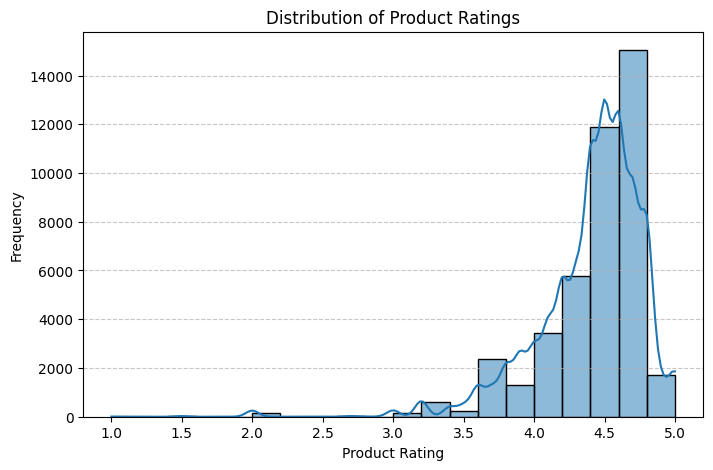

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['product_rating'], bins=20, kde=True)
plt.title('Distribution of Product Ratings')
plt.xlabel('Product Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Discounted Prices

This histogram shows the distribution of `discounted_price`. It can reveal typical price ranges and any outliers in product pricing after discounts.

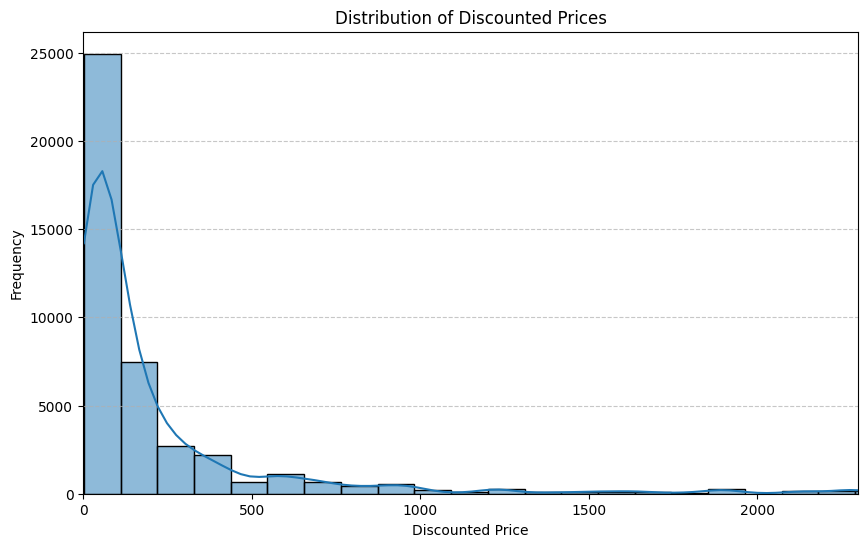

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['discounted_price'], bins=50, kde=True)
plt.title('Distribution of Discounted Prices')
plt.xlabel('Discounted Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, df['discounted_price'].quantile(0.99)) # Limit x-axis for better visualization due to outliers
plt.show()

In [ ]:
df.columns

Index(['product_rating', 'total_reviews', 'purchased_last_month',
       'discounted_price', 'original_price', 'discount_percentage',
       'product_title', 'is_best_seller', 'is_sponsored', 'has_coupon',
       'buy_box_availability', 'delivery_date', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discounted_amount', 'estimated_revenue', 'percentage_band'],
      dtype='object')

## Bivariate Analysis

In [ ]:
df[['is_sponsored','purchased_last_month']].head()

,is_sponsored,purchased_last_month
0,Sponsored,300
1,Sponsored,6000
2,Sponsored,2000
3,Organic,10000
4,Organic,10000


In [ ]:
df.groupby('is_sponsored').purchased_last_month.sum()

,purchased_last_month
is_sponsored,
Organic,15354850
Sponsored,28356800


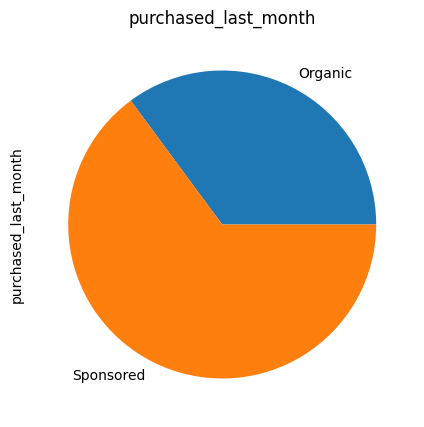

In [ ]:
df.groupby('is_sponsored').purchased_last_month.sum().plot(kind='pie',figsize=(5,5))
plt.title('purchased_last_month')
plt.xticks(rotation=0)
plt.show()

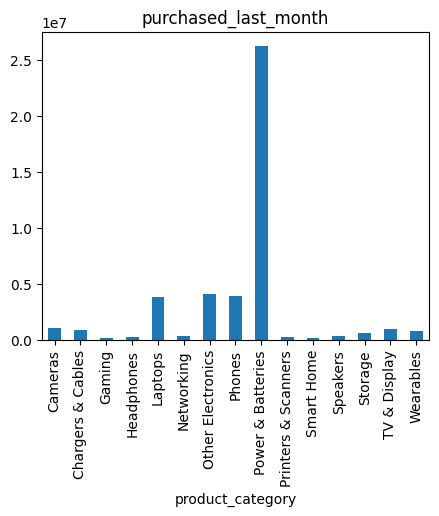

In [ ]:
df.groupby('product_category').purchased_last_month.sum().plot(kind='bar',figsize=(5,4))
plt.title('purchased_last_month')
plt.xticks(rotation=90)
plt.show()

### Relationship between Discount Percentage Band and Purchased Last Month

This bar plot shows the total `purchased_last_month` for each `percentage_band`. It helps to assess which discount ranges are most effective in driving sales.

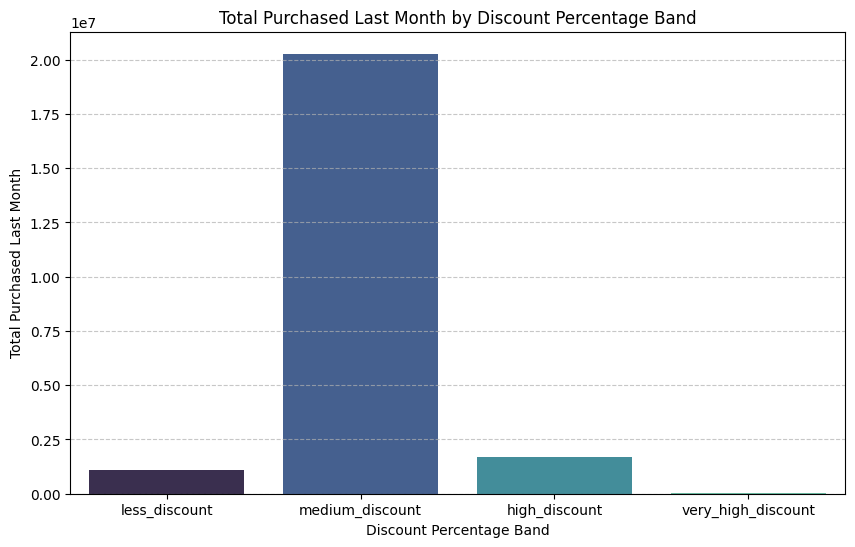

In [ ]:
total_purchases_by_discount = df.groupby('percentage_band', observed=False)['purchased_last_month'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='percentage_band', y='purchased_last_month', data=total_purchases_by_discount, palette='mako', hue='percentage_band', legend=False)
plt.title('Total Purchased Last Month by Discount Percentage Band')
plt.xlabel('Discount Percentage Band')
plt.ylabel('Total Purchased Last Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Relationship between Product Category and Estimated Revenue

This bar plot displays the total `estimated_revenue` for each `product_category`. This helps in identifying the most profitable product categories.

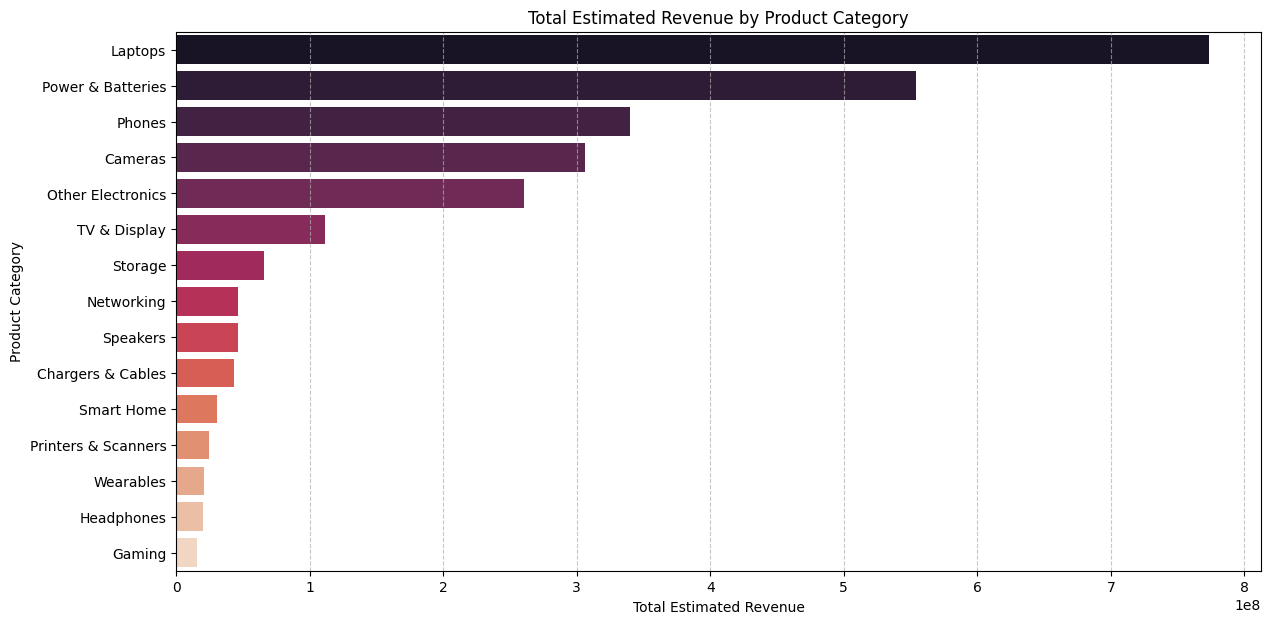

In [ ]:
total_revenue_by_category = df.groupby('product_category')['estimated_revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='estimated_revenue', y='product_category', data=total_revenue_by_category, palette='rocket', hue='product_category', legend=False)
plt.title('Total Estimated Revenue by Product Category')
plt.xlabel('Total Estimated Revenue')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Count of Best Seller Status

This bar plot illustrates the count of products categorized as 'Best Seller' versus 'No Badge'. It provides insight into the proportion of best-selling items in the dataset.

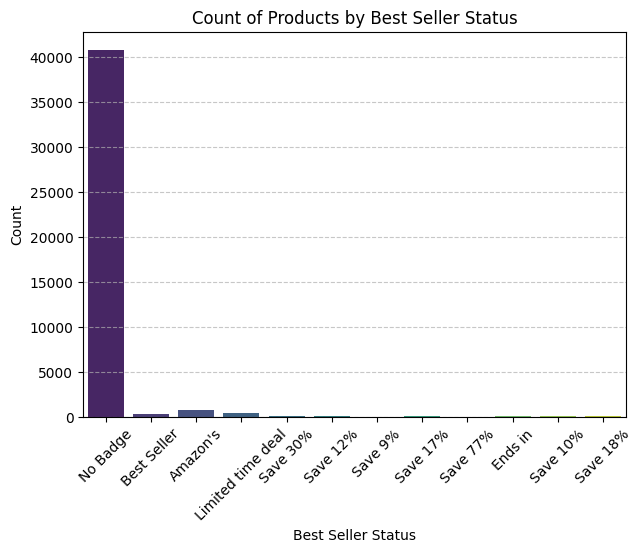

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(x='is_best_seller', data=df, palette='viridis', hue='is_best_seller', legend=False)
plt.title('Count of Products by Best Seller Status')
plt.xlabel('Best Seller Status')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Multivariate Analysis

### Product Category, Sponsorship, and Sales Metrics

This pivot table provides a comprehensive view of how `purchased_last_month`, `discounted_price`, and `original_price` are distributed across different `product_category` values, further segmented by `is_sponsored` status. This helps in understanding the interplay between product categories, sponsorship, and key sales metrics, revealing potential strategic insights.

In [ ]:
pd.pivot_table(df,index='product_category',
                  columns='is_sponsored',
                  values=('purchased_last_month', 'discounted_price', 'original_price' ),
                  aggfunc='sum')

discounted_price            original_price             \
is_sponsored                 Organic  Sponsored        Organic  Sponsored   
product_category                                                            
Cameras                   1390604.20  199835.56     1427179.93  206365.56   
Chargers & Cables          205546.36   24718.35      229224.38   26759.62   
Gaming                     111551.38    3547.88      117789.23    3849.88   
Headphones                 112487.40   23505.99      127188.94   23817.01   
Laptops                   3849807.30  167521.87     4164103.95  179810.33   
Networking                 138777.34   91559.83      177886.89   91710.42   
Other Electronics         1196671.14   64915.83     1219472.53   65471.76   
Phones                     882410.88  109738.43      916914.01  121721.40   
Power & Batteries          107917.61   49233.66      110499.42   51900.54   
Printers & Scanners        138649.36        NaN      148553.53        NaN   
Smart Home                 141580.86    3270.91      146605.58    3752.91   
Speakers                   197654.78   41581.79      207755.31   42348.74   
Storage                    170095.14   51716.63      179047.29   62060.63   
TV & Display               306691.98  157249.40      318212.03  159508.90   
Wearables                  114344.47     252.95      115955.51     411.66   

                    purchased_last_month              
is_sponsored                     Organic   Sponsored  
product_category                                      
Cameras                         873000.0    177900.0  
Chargers & Cables               830950.0     48600.0  
Gaming                          149700.0      2400.0  
Headphones                      206100.0     24250.0  
Laptops                        3235100.0    593150.0  
Networking                      270750.0     51100.0  
Other Electronics              3994500.0     97300.0  
Phones                         2194750.0   1686200.0  
Power & Batteries              1562850.0  24607400.0  
Printers & Scanners             290450.0         NaN  
Smart Home                      129600.0      1600.0  
Speakers                        256950.0     45000.0  
Storage                         461950.0    166100.0  
TV & Display                    641350.0    325800.0  
Wearables                       256850.0    530000.0

### Correlation Heatmap of Numerical Features

This heatmap visualizes the Pearson correlation coefficients between all numerical features in the dataset. It helps in identifying strong linear relationships between variables, which can be useful for feature selection or understanding underlying data structures.

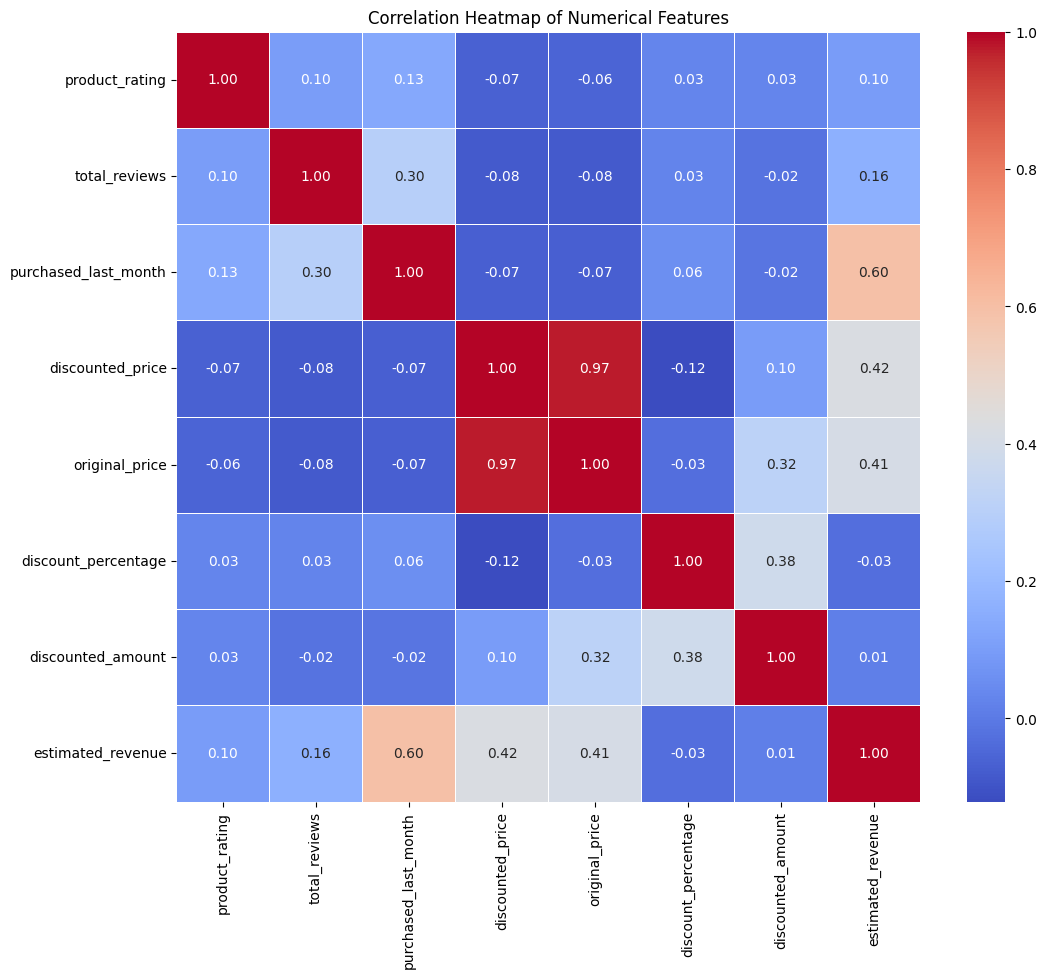

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Purchased Last Month by Product Category and Best Seller Status

This grouped bar plot shows the total `purchased_last_month` for each `product_category`, further broken down by `is_best_seller` status. This can highlight which categories benefit most from best-seller recognition.

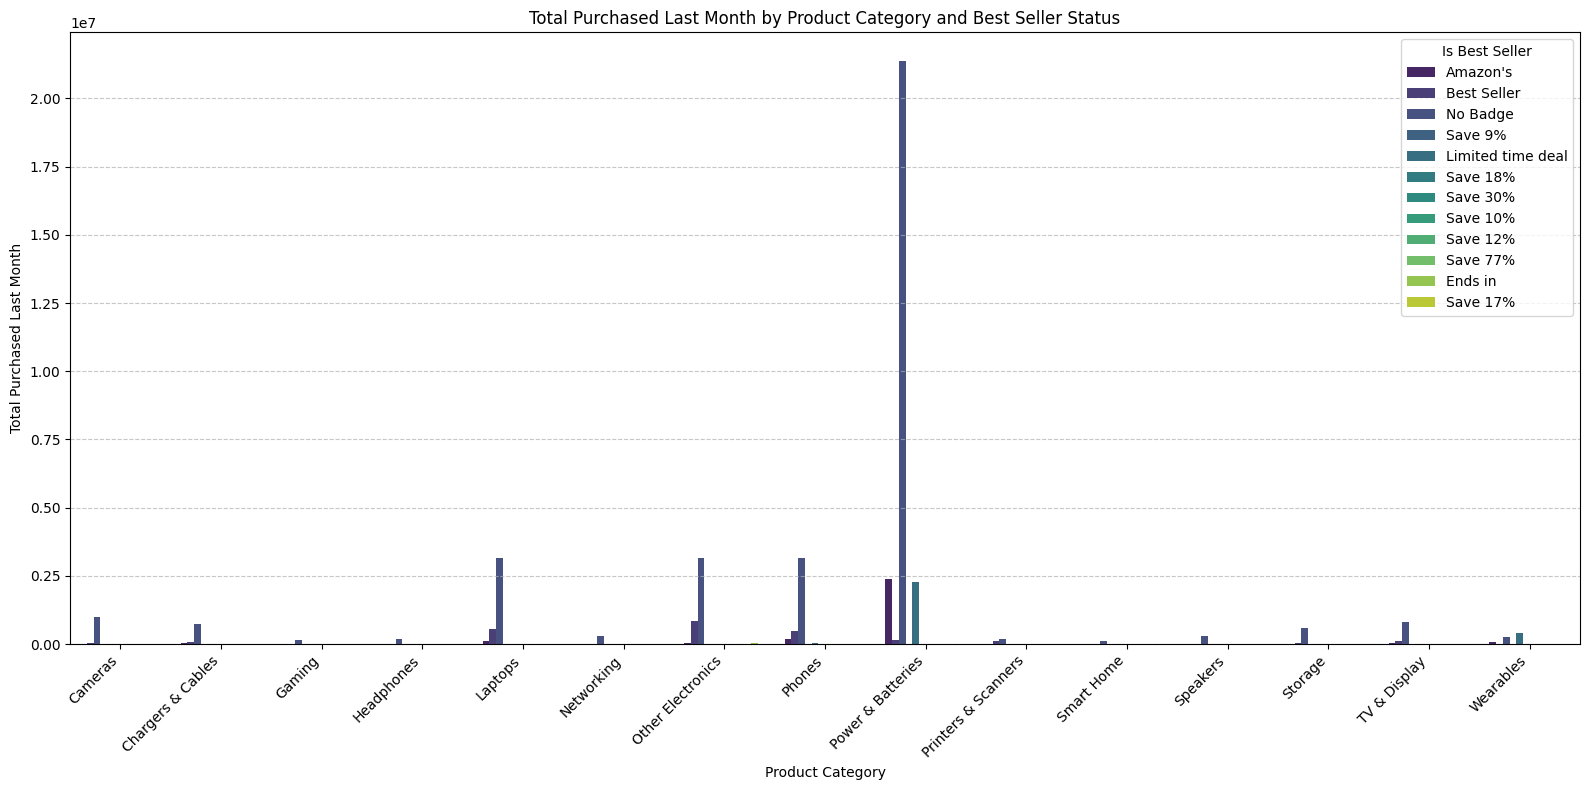

In [ ]:
plt.figure(figsize=(16, 8))
sns.barplot(x='product_category', y='purchased_last_month', hue='is_best_seller', data=df.groupby(['product_category', 'is_best_seller'])['purchased_last_month'].sum().reset_index(), palette='viridis')
plt.title('Total Purchased Last Month by Product Category and Best Seller Status')
plt.xlabel('Product Category')
plt.ylabel('Total Purchased Last Month')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Is Best Seller')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Key Findings and Conclusion

**Summarize your main findings here from all the analyses conducted.**

For example:

*   **Missing Data**: Most missing values were successfully imputed using median for numerical and mode for categorical features. The `sustainability_tags` column was dropped due to high sparsity.
*   **Feature Engineering**: New features like `discounted_amount`, `estimated_revenue`, and `percentage_band` were created to provide additional dimensions for analysis.
*   **Sponsorship Impact**: (Based on your plot) Explain if sponsored products significantly outperform organic ones in terms of purchases, or if the impact varies.
*   **Category Performance**: (Based on your plot) Identify the top-performing product categories by `purchased_last_month`.
*   **Pricing & Discounts**: Discuss any observed trends regarding discount levels and their correlation with sales or product ratings.
*   **Multivariate Insights**: Highlight any interesting patterns from the pivot table, such as categories where sponsored products have a significant advantage in sales or pricing.

This EDA has provided foundational insights into the Amazon product sales data. Further analysis could involve building predictive models for sales, optimizing pricing, or identifying target product categories for marketing campaigns.

## Overall Observations

Based on the Exploratory Data Analysis conducted:

*   **Missing Data Handling**: Numerical missing values were imputed with their medians, and categorical ones with their modes, ensuring no loss of rows. The `sustainability_tags` column was dropped due to an overwhelming percentage of missing values.
*   **Data Type Conversion**: Dates were correctly converted to datetime objects, and count-based features (`total_reviews`, `purchased_last_month`) were cast to integers for appropriate handling.
*   **Feature Engineering**: New, insightful features were successfully created:
    *   `discounted_amount`: Provides a direct measure of the monetary saving.
    *   `estimated_revenue`: Offers an approximation of sales performance for each product.
    *   `percentage_band`: Categorizes discounts into 'less_discount', 'medium_discount', 'high_discount', and 'very_high_discount', which can be useful for strategy analysis.
*   **Univariate Analysis - Discount Distribution**: The `percentage_band` analysis showed that 'medium_discount' (10-40%) is the most common range, followed by 'less_discount' (0-10%). This indicates a strategy of moderate discounting.
*   **Bivariate Analysis - Sponsorship Impact**: Sponsored products, despite being fewer in number, demonstrate significantly higher `purchased_last_month` figures compared to organic products. This suggests a strong correlation between sponsorship and sales volume.
*   **Bivariate Analysis - Category Performance**: Product categories such as 'Power & Batteries', 'Other Electronics', and 'Laptops' show the highest total `purchased_last_month` values, indicating their popularity or high sales volume within the dataset.
*   **Multivariate Analysis - Category & Sponsorship**: The pivot table revealed interesting patterns. For instance, 'Power & Batteries' and 'Phones' categories have a substantial portion of their `purchased_last_month` coming from sponsored listings, often at competitive discounted prices compared to their original prices.